# Module 06 — Clustering with Resolution Optimization (v5 + tiered v4)

This notebook visualizes clustering results from `scripts/06_clustering.py`
for **both** the v5 atlas (CCA-flat) and the new **tiered v4 atlas**
(Seurat v4 SCT + CCA, run per compartment with mesenchymal / non-mesenchymal
tiers split before integration). Leiden clustering is run per tier on the
tier-specific embedding with automated resolution optimization.

**Sections**
- §1–4 — v5 atlas (CCA-flat, status: completed 2026-03-25)
- §5 — tiered v4 atlas (status: Module 06 complete 2026-05-22; pending human checkpoint)

**v5 cluster counts:** NP 12 · AF 12 · CEP 9 · all_cells 15

**Tiered v4 cluster counts (2026-05-22 rerun, post NP-rescue + 50-cell non-mes threshold):** NP 18 · AF 19 · CEP 19 · all_cells 24

**Data sources**
- v5: `data/integrated/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/clustering_resolution_optimization/`
- tiered v4: `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/tiered_v4/clustering_resolution_optimization/`

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

import io
from pathlib import Path

import anndata
anndata.settings.allow_write_nullable_strings = True

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from PIL import Image as PILImage
from IPython.display import Image, display, Markdown

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# JPEG-compression helpers — keep notebook under GitHub's ~10 MB render limit.
# Source figures stay full-resolution in results/.
UMAP_MAX_WIDTH = 1200
UMAP_JPEG_QUALITY = 90

def _encode_jpeg(img, max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY):
    img = img.convert('RGB')
    if img.width > max_width:
        ratio = max_width / img.width
        img = img.resize((max_width, int(img.height * ratio)), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality, optimize=True)
    return buf.getvalue()

def render_fig(fig, max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY, dpi=110):
    """Render a matplotlib figure through the PIL/JPEG pipeline."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    jpeg_bytes = _encode_jpeg(PILImage.open(buf), max_width, quality)
    display(Image(data=jpeg_bytes, format='jpeg'))

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
OPT_DIR = BASE / 'results' / 'integration' / 'clustering_resolution_optimization'
FIG_DIR = BASE / 'results' / 'integration'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COMPARTMENTS = {
    'NP': INT_DIR / 'NP.h5ad',
    'AF': INT_DIR / 'AF.h5ad',
    'CEP': INT_DIR / 'CEP.h5ad',
    'all_cells': INT_DIR / 'all_cells.h5ad',
}

for name, path in COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')


  NP: found
  AF: found
  CEP: found
  all_cells: found


## 1. Resolution Optimization Diagnostics (v5)

The resolution parameter controls the granularity of Leiden clustering. A
resolution scan evaluates multiple values and selects the one that optimizes
a combination of silhouette score and cluster stability. Plots below show
the optimization landscape for each compartment and tier.


Resolution optimization plots: 8


### Af Mesenchymal

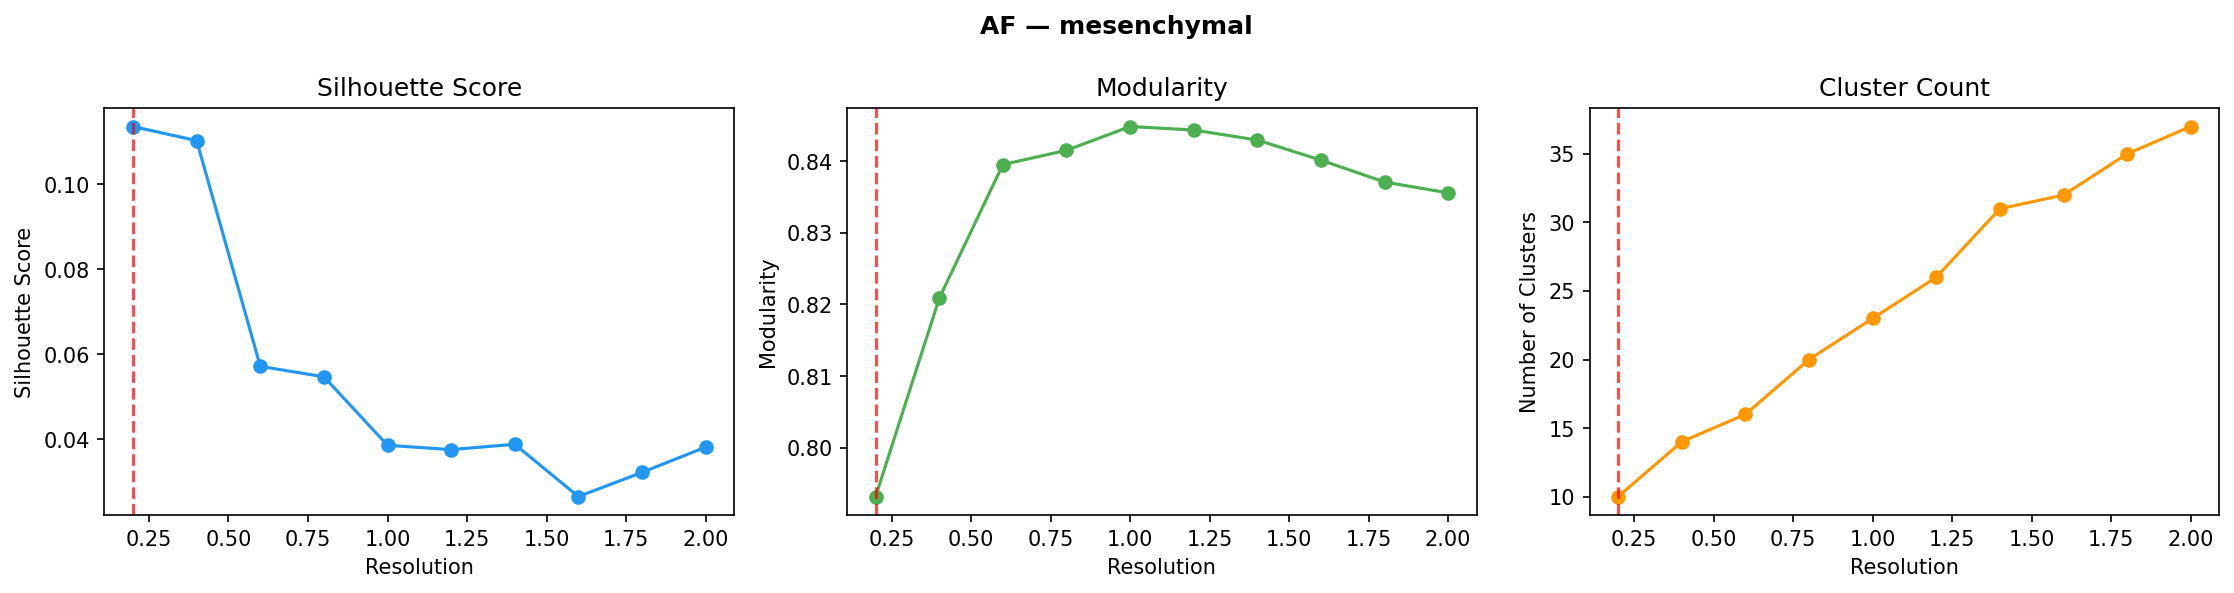

### Af Non Mesenchymal

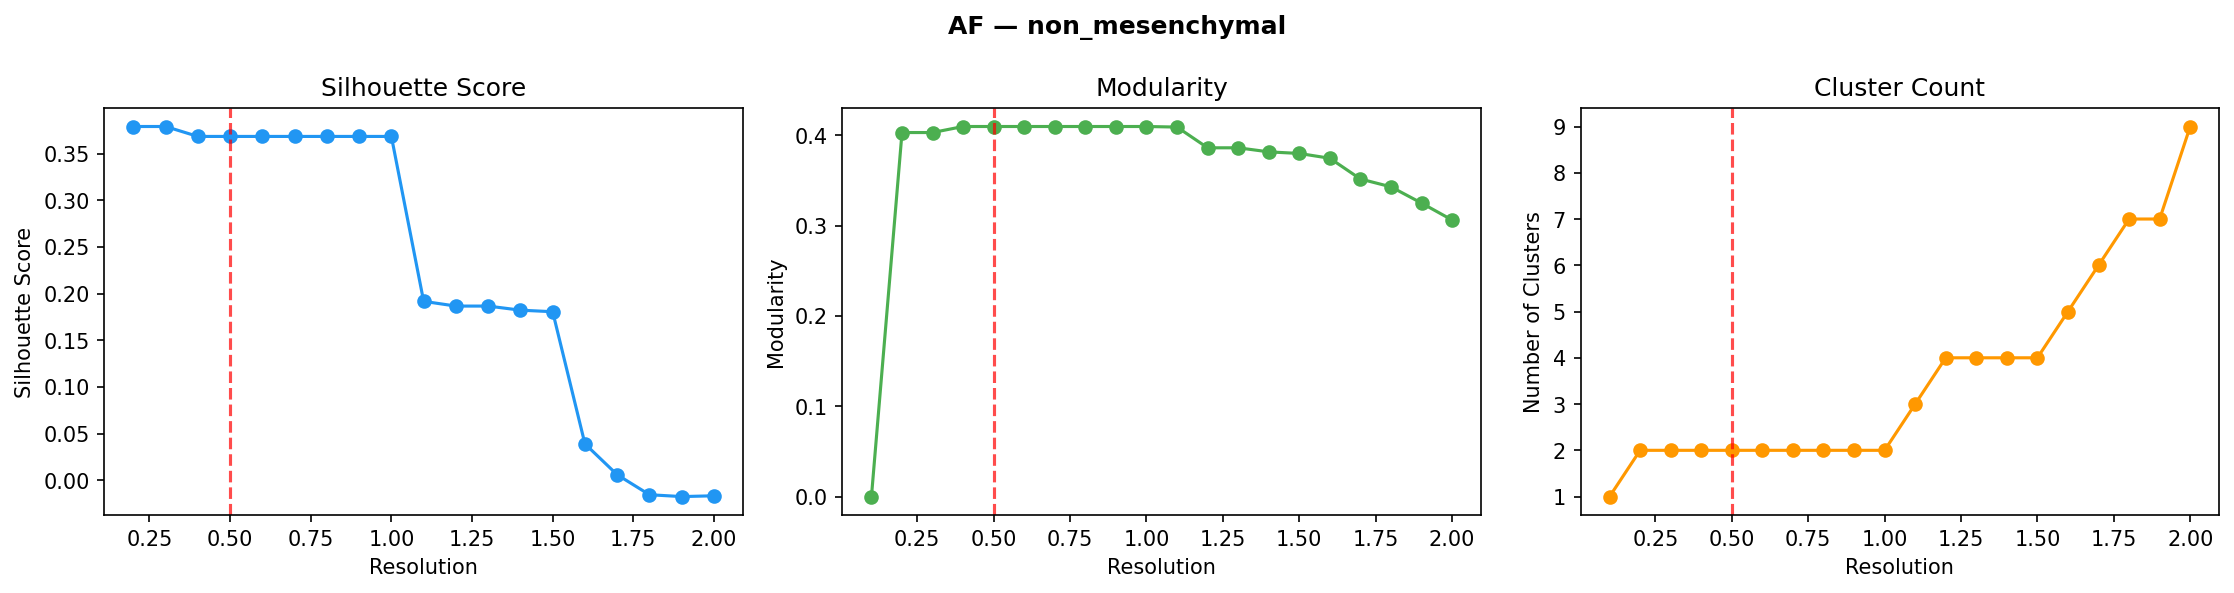

### Cep Mesenchymal

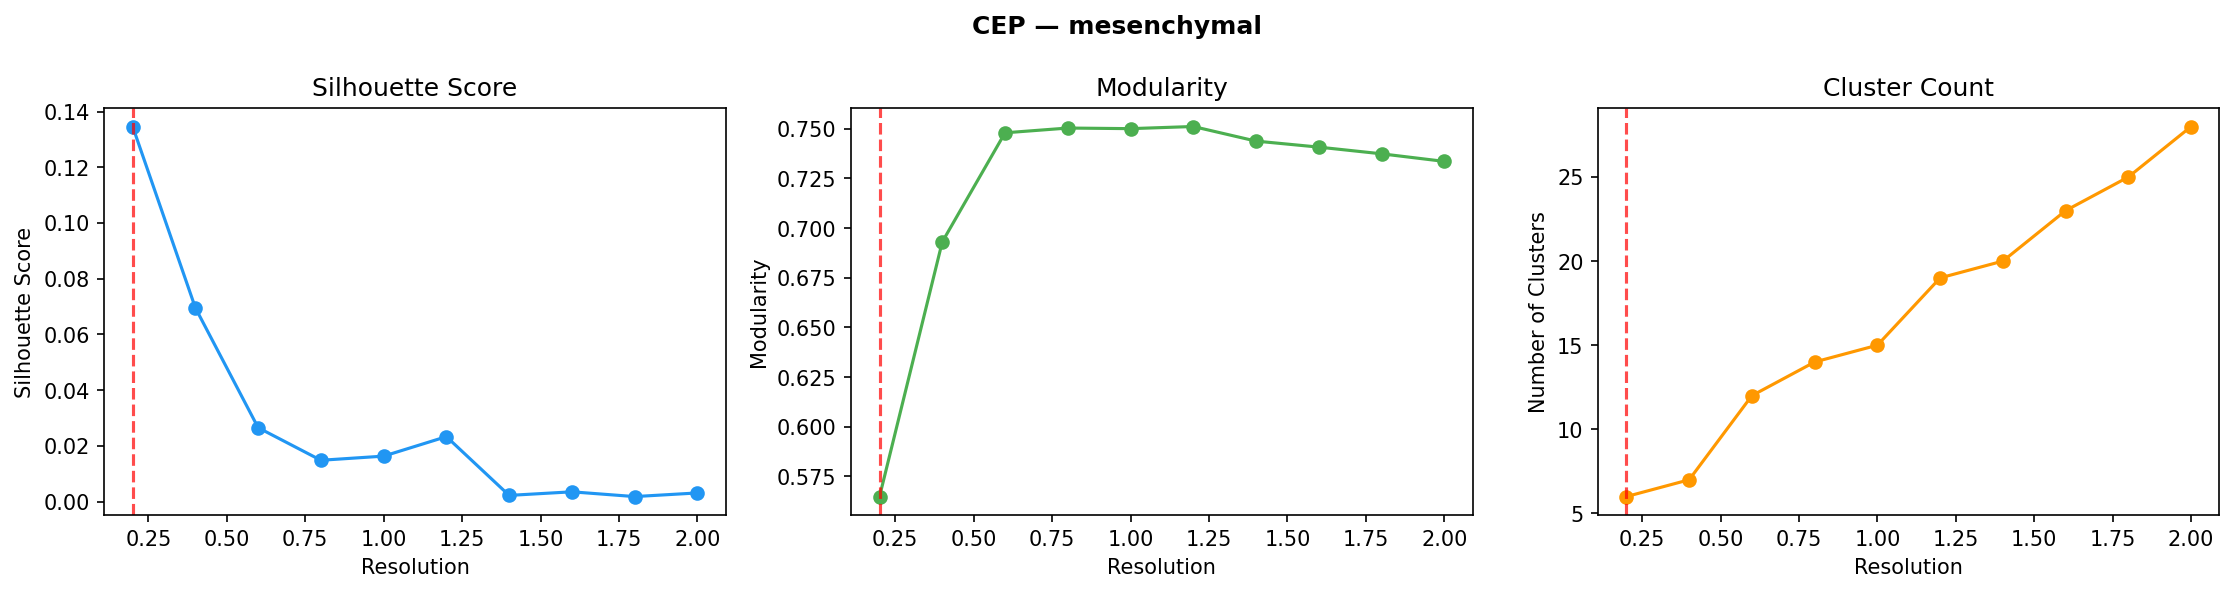

### Cep Non Mesenchymal

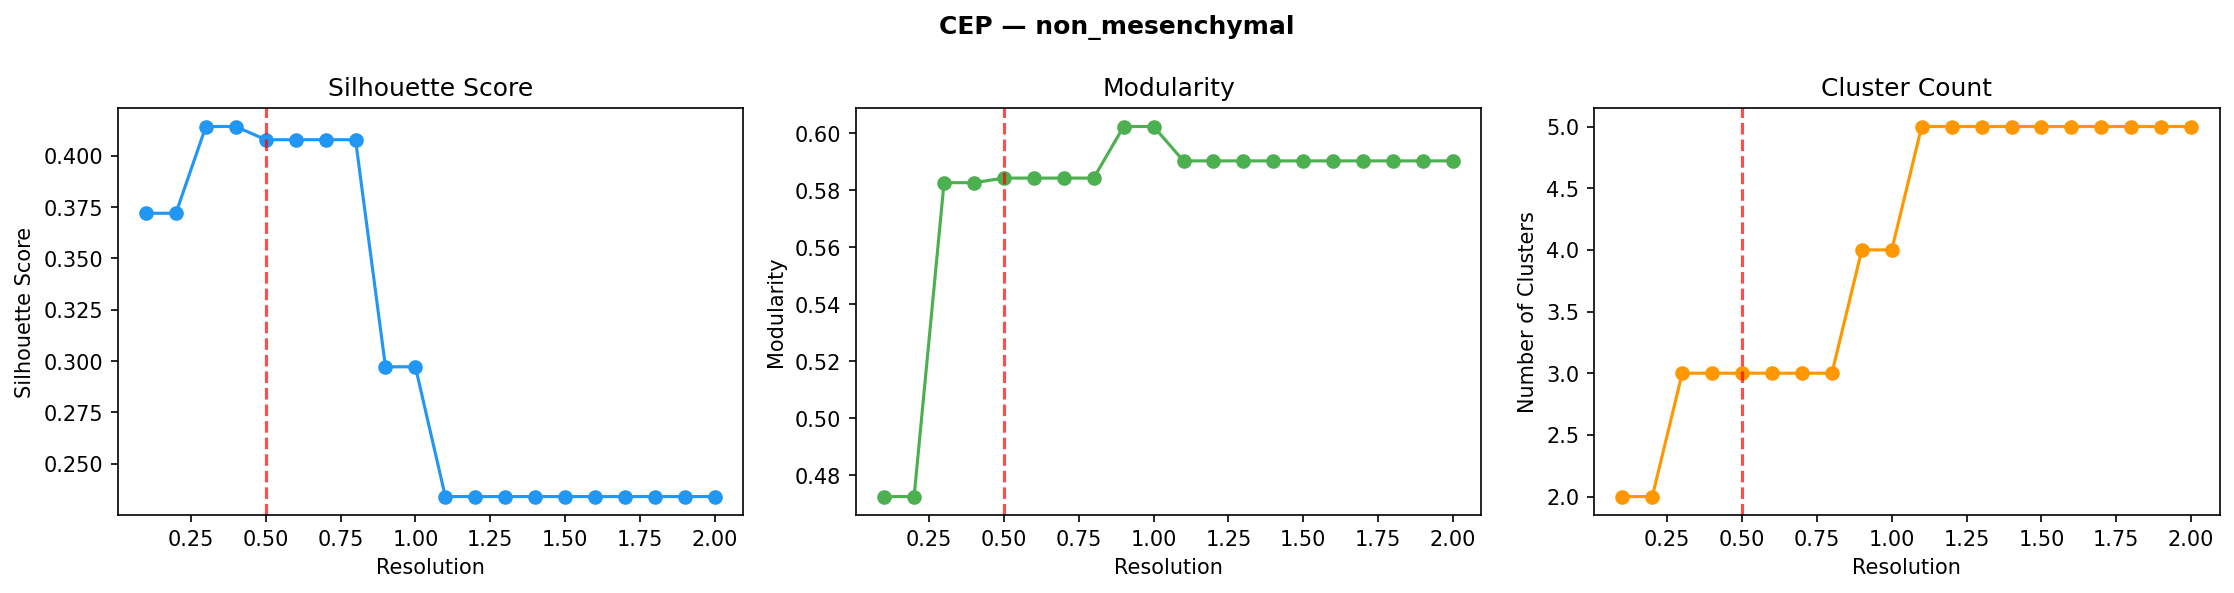

### Np Mesenchymal

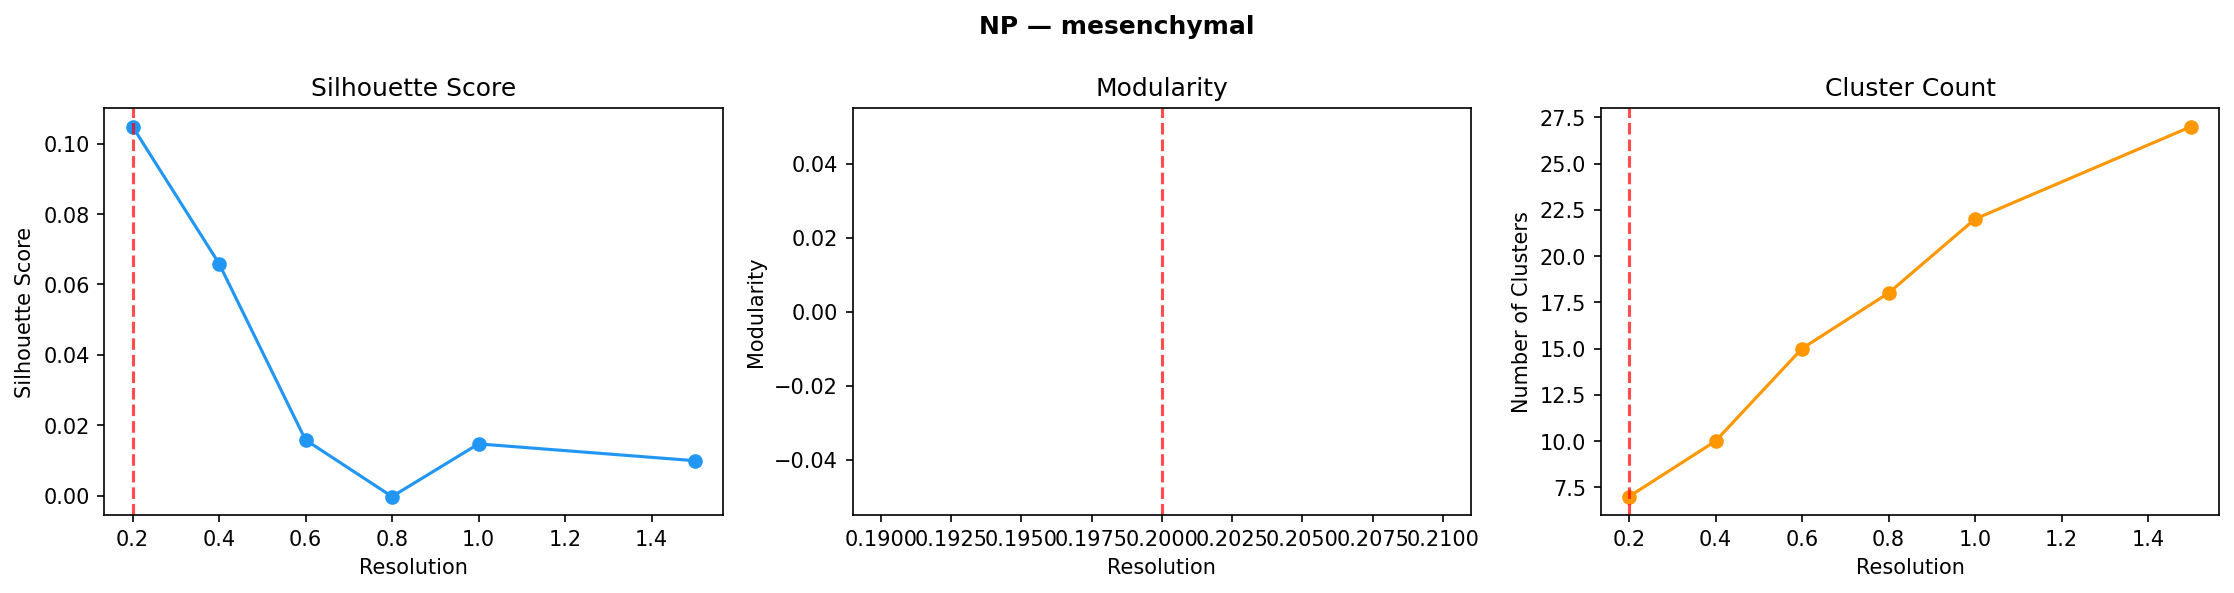

### Np Non Mesenchymal

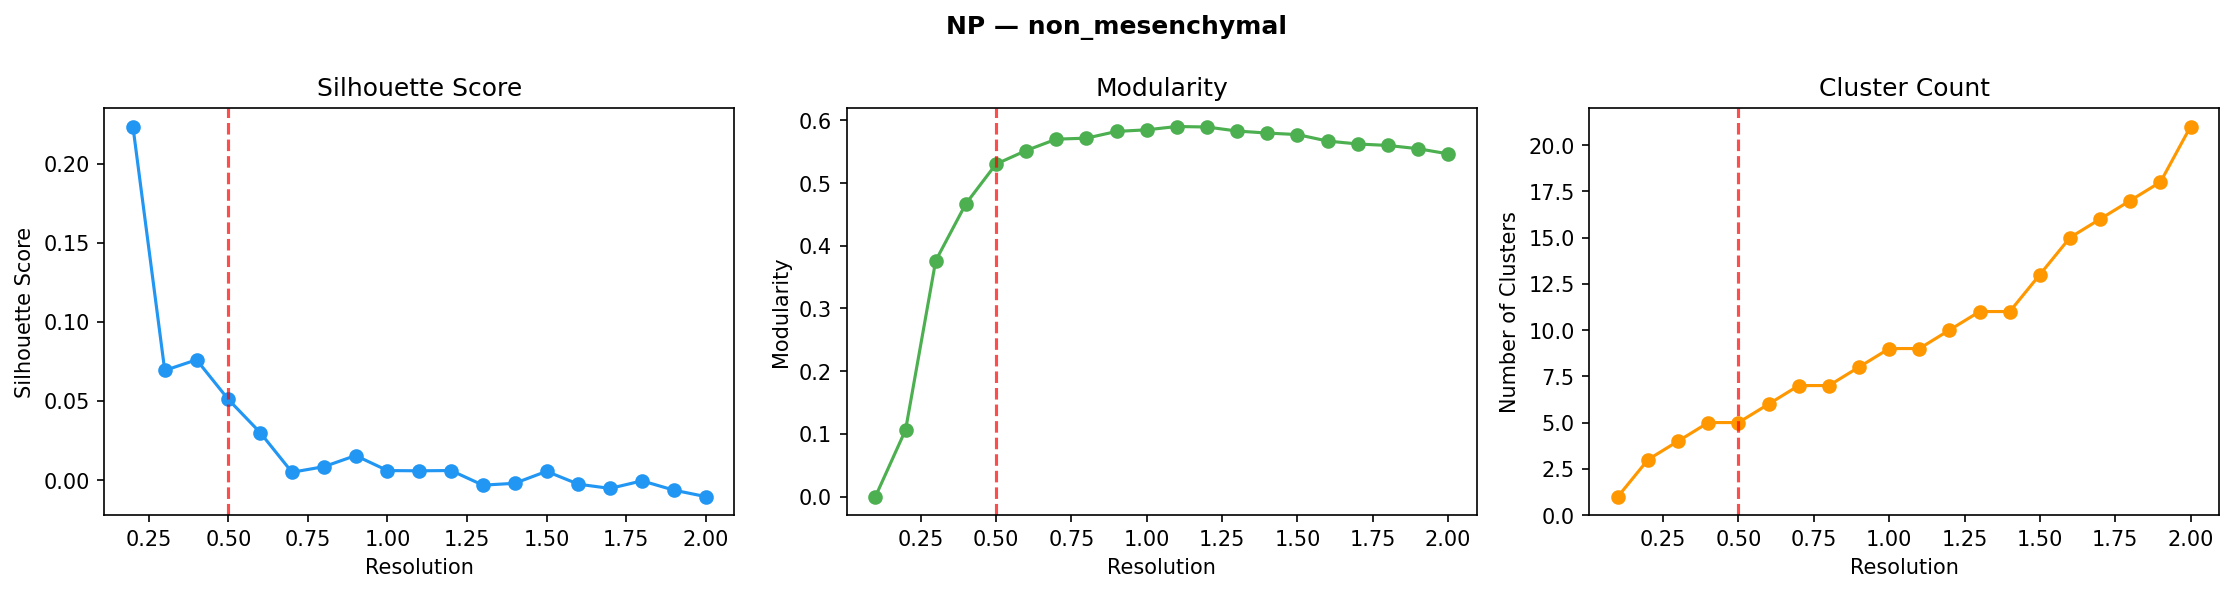

### All Cells Mesenchymal

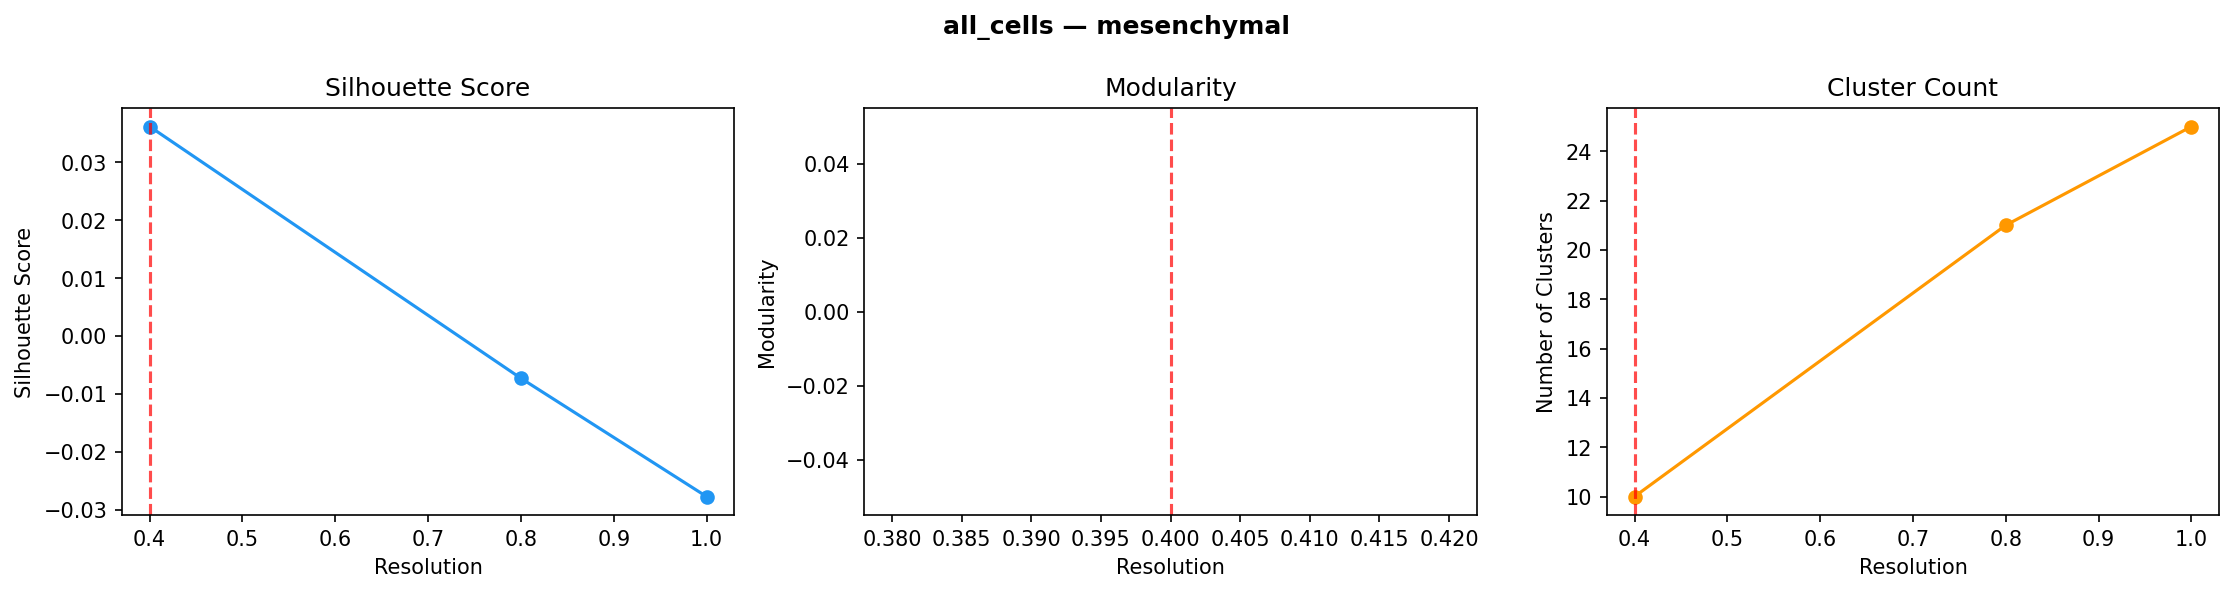

### All Cells Non Mesenchymal

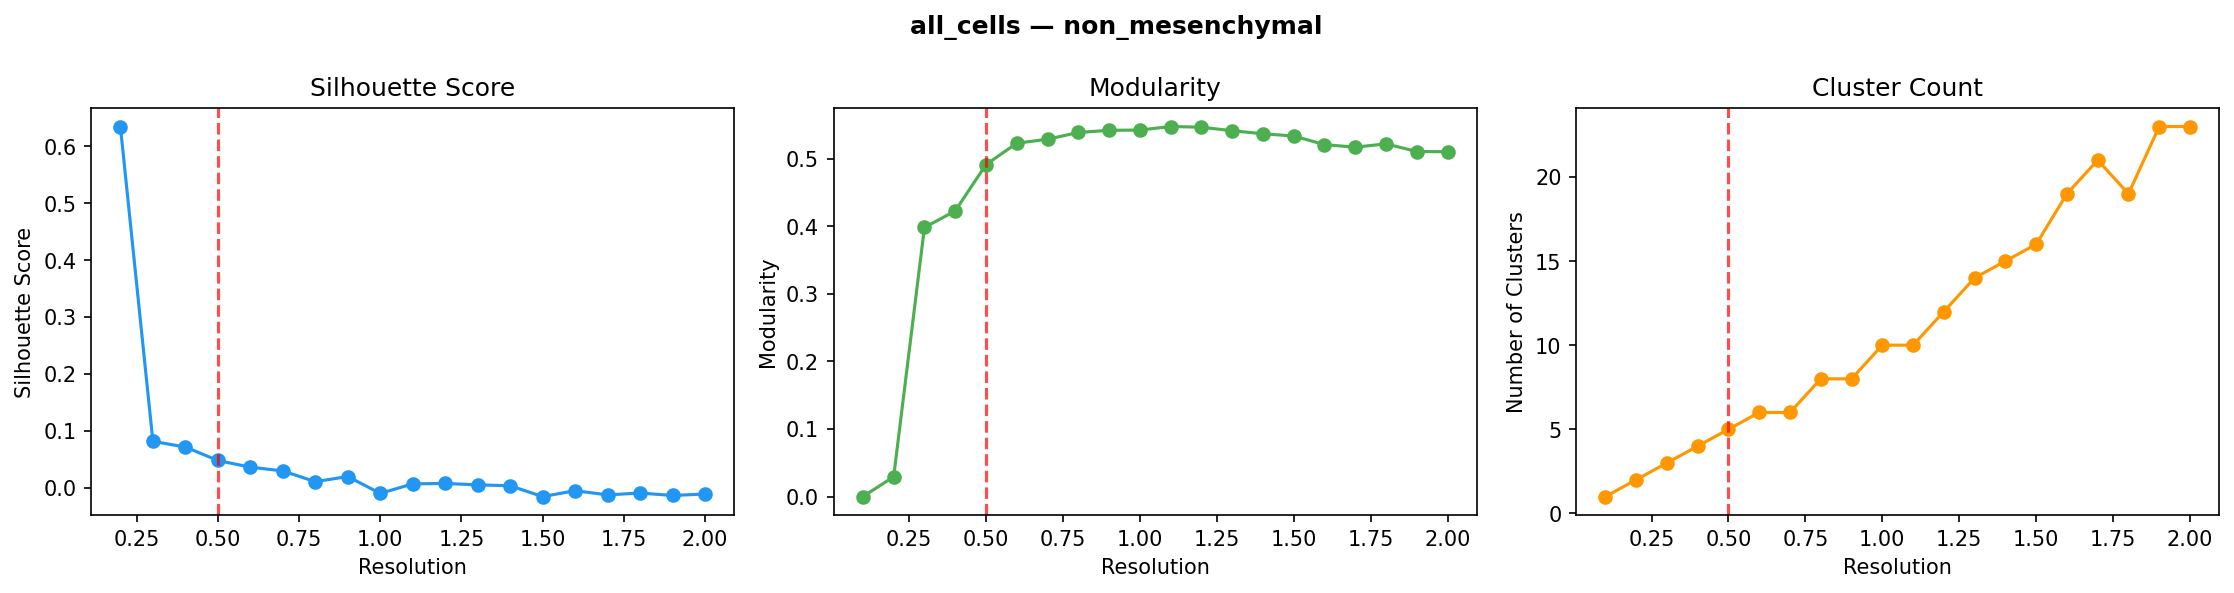

In [2]:
# Display resolution optimization plots for each compartment/tier
opt_plots = sorted(OPT_DIR.glob('*_optimization.png'))
print(f'Resolution optimization plots: {len(opt_plots)}')

for fpath in opt_plots:
    label = fpath.stem.replace('_optimization', '').replace('_', ' ').title()
    display(Markdown(f'### {label}'))
    display(Image(filename=str(fpath), width=800))

## 2. Resolution Scan Tables (v5)

Selected resolutions and metrics for each compartment/tier combination.


In [3]:
# Display resolution scan tables
res_tables = sorted(OPT_DIR.glob('*_resolutions.tsv'))
print(f'Resolution scan tables: {len(res_tables)}')

for fpath in res_tables:
    label = fpath.stem.replace('_resolutions', '').replace('_', ' ').title()
    df = pd.read_csv(fpath, sep='\t')
    display(Markdown(f'### {label}'))
    display(df.style.set_caption(f'{label} — Resolution Scan Results'))

Resolution scan tables: 8


### Af Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.200000,10,0.113650,0.793193
1,0.400000,14,0.110320,0.820853
2,0.600000,16,0.057175,0.839526
3,0.800000,20,0.054726,0.841514
4,1.000000,23,0.038593,0.844837
5,1.200000,26,0.037576,0.844344
6,1.400000,31,0.038834,0.842949
7,1.600000,32,0.026518,0.840142
8,1.800000,35,0.032216,0.837089
9,2.000000,37,0.038148,0.835573


### Af Non Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.100000,1,nan,0.000000
1,0.200000,2,0.378921,0.403187
2,0.300000,2,0.378921,0.403187
3,0.400000,2,0.368282,0.409869
4,0.500000,2,0.368282,0.409869
5,0.600000,2,0.368282,0.409869
6,0.700000,2,0.368282,0.409869
7,0.800000,2,0.368282,0.409869
8,0.900000,2,0.368282,0.409869
9,1.000000,2,0.368282,0.409869


...

,resolution,n_clusters,silhouette,modularity
0,0.100000,1,nan,0.000000
1,0.200000,3,0.223412,0.106312
2,0.300000,4,0.069269,0.376228
3,0.400000,5,0.076017,0.467009
4,0.500000,5,0.050921,0.530321
5,0.600000,6,0.030003,0.551945
6,0.700000,7,0.004937,0.570122
7,0.800000,7,0.008447,0.571688
8,0.900000,8,0.015479,0.582442
9,1.000000,9,0.005999,0.585001


### All Cells Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.400000,10,0.036124,nan
1,0.800000,21,-0.007291,nan
2,1.000000,25,-0.027690,nan


### All Cells Non Mesenchymal

,resolution,n_clusters,silhouette,modularity
0,0.100000,1,nan,0.000000
1,0.200000,2,0.634397,0.029309
2,0.300000,3,0.081752,0.398008
3,0.400000,4,0.071703,0.422472
4,0.500000,5,0.048110,0.491067
5,0.600000,6,0.036371,0.522642
6,0.700000,6,0.029799,0.528545
7,0.800000,8,0.010896,0.538557
8,0.900000,8,0.019994,0.541758
9,1.000000,10,-0.009644,0.542107


## 3. Cluster UMAP per Compartment (v5)

UMAP colored by Leiden cluster labels for each compartment. This shows the
spatial distribution of clusters on the CCA-integrated embedding.


### NP — 12 Leiden Clusters

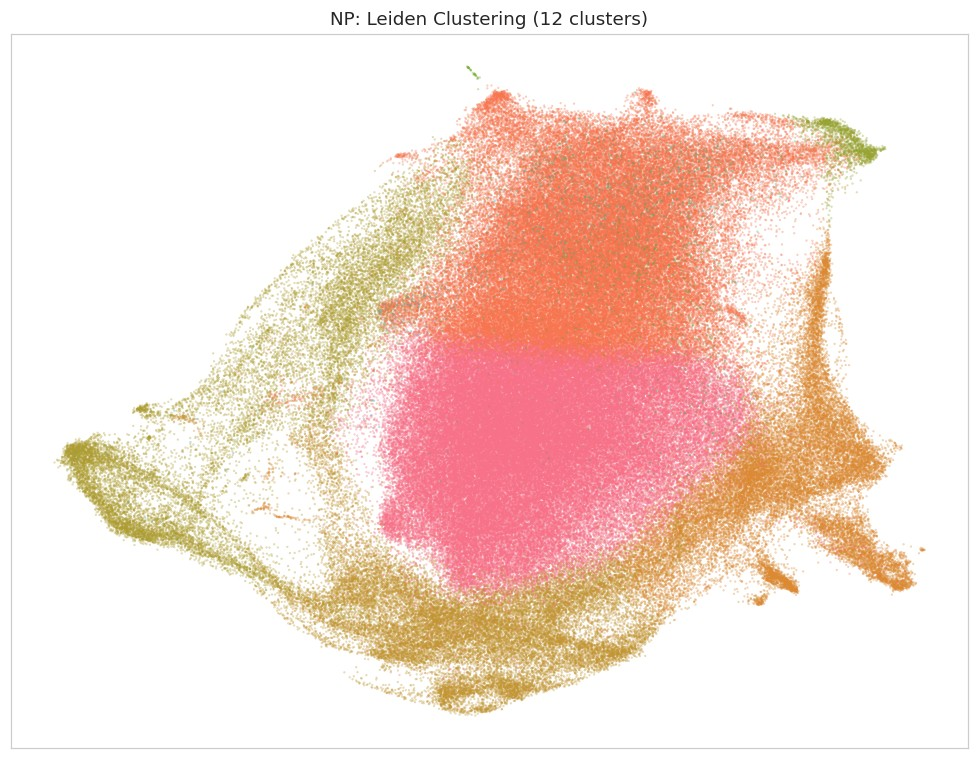

### AF — 12 Leiden Clusters

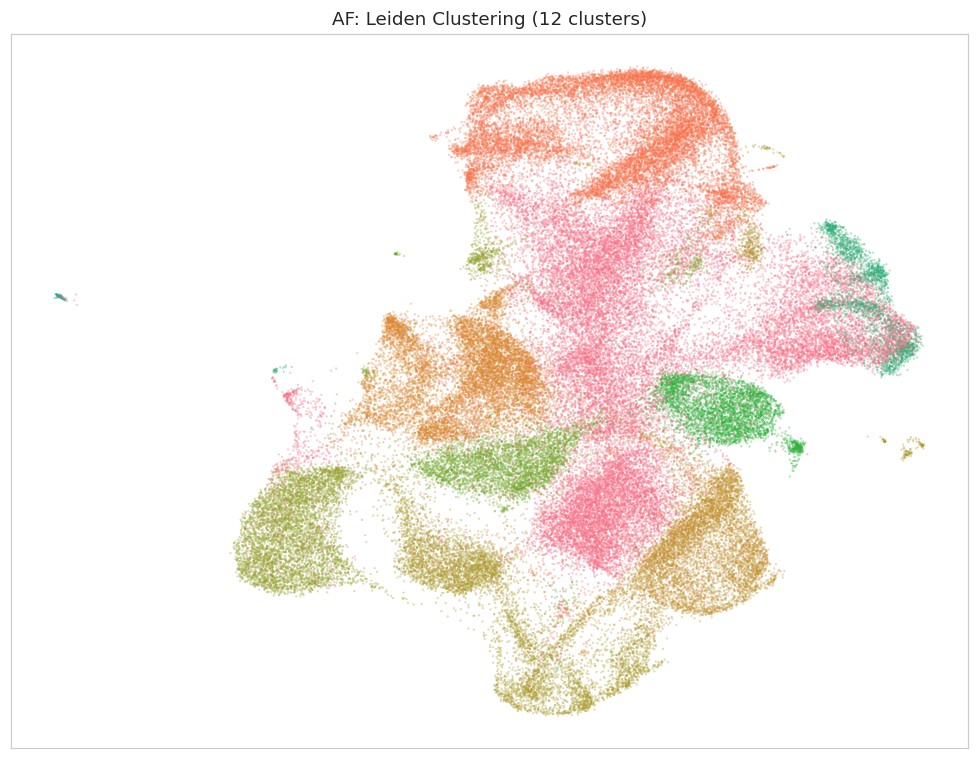

### CEP — 9 Leiden Clusters

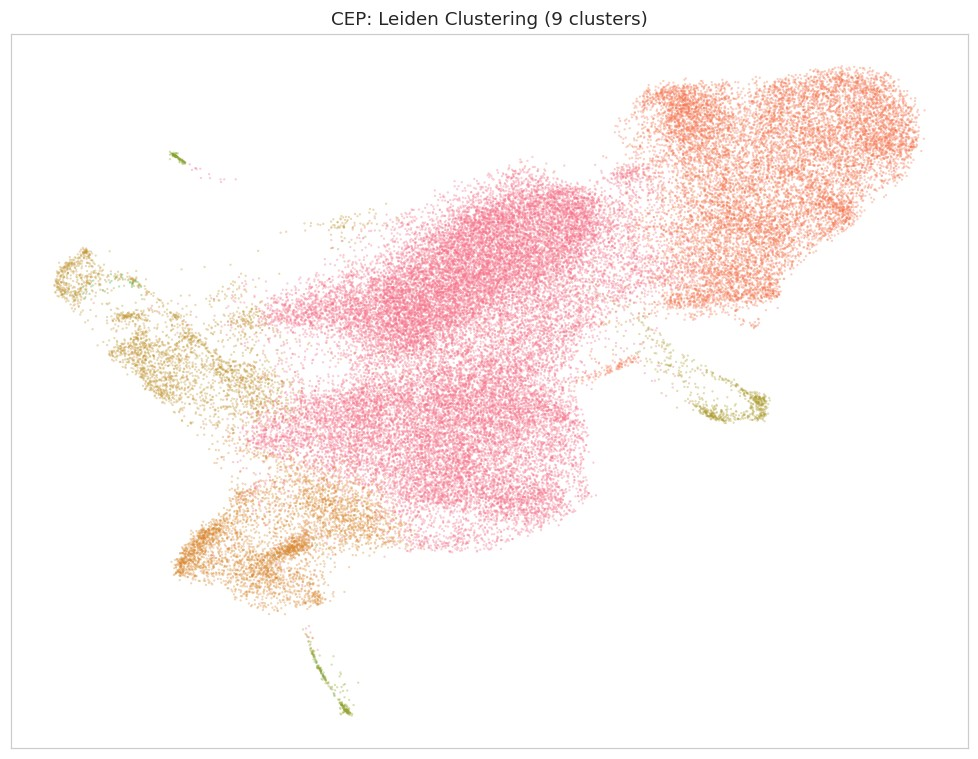

In [4]:
for comp_name, comp_path in [('NP', COMPARTMENTS['NP']),
                              ('AF', COMPARTMENTS['AF']),
                              ('CEP', COMPARTMENTS['CEP'])]:
    if not comp_path.exists():
        print(f'{comp_name}: file not found')
        continue

    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    umap = adata.obsm['X_umap'][:] if 'X_umap' in adata.obsm else None
    n_clusters = obs_df['leiden'].nunique() if 'leiden' in obs_df.columns else 0
    adata.file.close()

    if umap is None or 'leiden' not in obs_df.columns:
        print(f'{comp_name}: missing UMAP or leiden column')
        continue

    display(Markdown(f'### {comp_name} — {n_clusters} Leiden Clusters'))

    unique_clusters = sorted(obs_df['leiden'].unique(),
                              key=lambda x: int(x) if str(x).isdigit() else x)
    palette = dict(zip(unique_clusters,
                       sns.color_palette('husl', max(len(unique_clusters), 20))))

    fig, ax = plt.subplots(figsize=(9, 7))
    idx = np.random.RandomState(42).permutation(len(umap))
    labels = obs_df['leiden'].values
    colors = [palette.get(labels[i], '#cccccc') for i in idx]
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.2, alpha=0.4, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{comp_name}: Leiden Clustering ({n_clusters} clusters)', fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'notebook_06_{comp_name}_leiden_umap.png', dpi=150, bbox_inches='tight')
    render_fig(fig)

    del obs_df, umap


## 4. Cluster Size Distributions (v5)

Bar chart of cluster sizes for each compartment, showing how cells are
distributed across clusters.


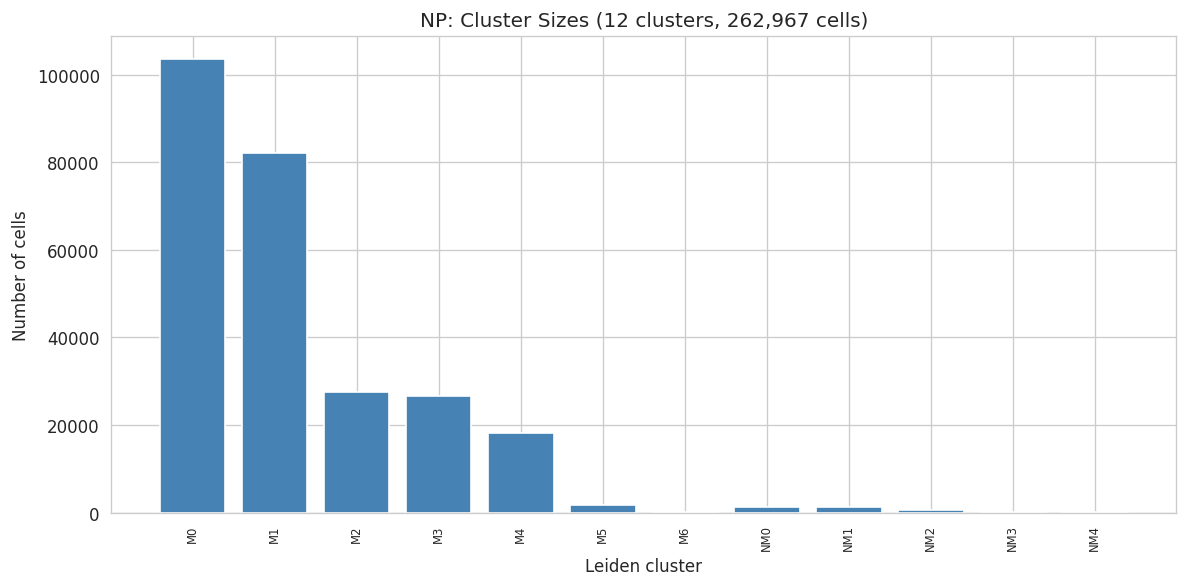

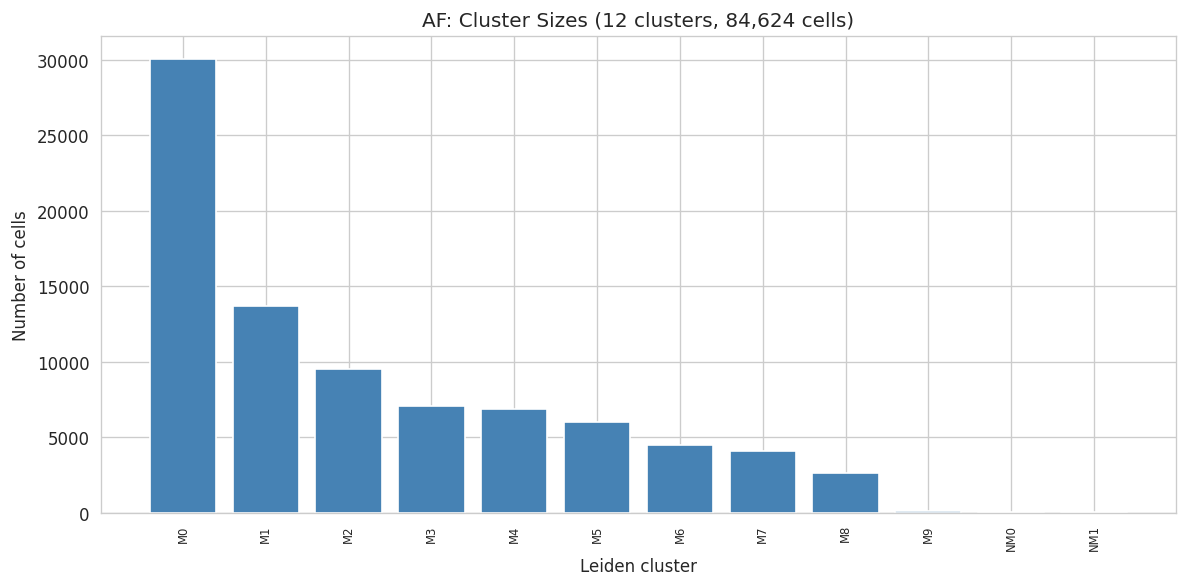

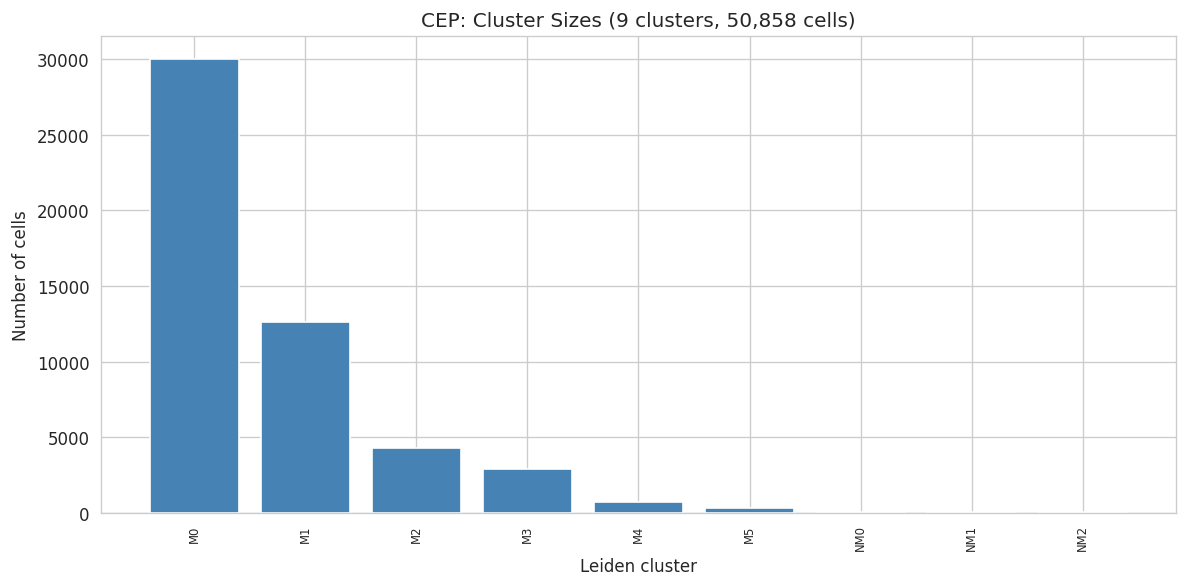

In [5]:
# Cluster size bar charts per compartment
for comp_name, comp_path in [('NP', COMPARTMENTS['NP']),
                              ('AF', COMPARTMENTS['AF']),
                              ('CEP', COMPARTMENTS['CEP'])]:
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'leiden' not in obs_df.columns:
        continue

    counts = obs_df['leiden'].value_counts().sort_index(
        key=lambda x: x.astype(int) if x.str.isdigit().all() else x)

    fig, ax = plt.subplots(figsize=(max(10, len(counts) * 0.35), 5))
    ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=90, fontsize=7)
    ax.set_ylabel('Number of cells')
    ax.set_xlabel('Leiden cluster')
    ax.set_title(f'{comp_name}: Cluster Sizes ({len(counts)} clusters, {len(obs_df):,} cells)')
    fig.tight_layout()
    plt.show()

    del obs_df

## 5. Tiered v4 Atlas — Module 06 (2026-05-22 rerun, post NP-rescue + 50-cell non-mes threshold)

After the per-compartment metric review (notebook 05 §6), the atlas was
re-run on the tiered v4 integration (Seurat v4 SCT + CCA, mesenchymal /
non-mesenchymal split before integration). Cells live at
`data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad`; the v5 outputs
remain on disk untouched. Module 06 ran independently per compartment via
`scripts/06_clustering.py --input-dir data/integrated/tiered_v4 \
--output-dir results/integration/tiered_v4`.

**2026-05-22 rerun** consolidates two upstream changes:

- **NP unassigned rescue (commits `15944f1`, `a26525c`).** Module 04 cell-
  class panels were extended so previously-unassigned (`unknown`) cells
  could be re-tiered into mesenchymal vs non-mesenchymal. Adaptive HVG
  selection in 05k honors `--hvg-cap` / `--max-cfo-product` to keep CCA
  tractable on the larger tier objects.
- **Non-mes per-study threshold raised 5 → 50 cells (this rerun).** Below
  the new floor, studies are dropped from the non-mes tier rather than
  forced through a simple-merge fallback that produced study-segregated
  UMAP lobes (no real batch correction). AF lost `GSE199866_AF` (7 cells)
  to the drop; every surviving non-mes object now clears CCA's
  `dims=1:50` requirement.

**Selection rule unchanged from PR #4 (commit `d44a0c4`):** silhouette
and modularity are min-max normalized within the full sweep (res =
0.1 → 2.0, step 0.1), averaged into a combined score, and the
argmax is chosen with ties broken on silhouette.

**Final cluster counts (2026-05-22):**

| Compartment | Mes res / clusters         | Non-mes res / clusters       | Total |
|-------------|----------------------------|------------------------------|-------|
| NP          | 0.4 / 9 (187,257 cells)    | 0.3 / 9 (75,667 cells)       | 18    |
| AF          | 0.3 / 12 (72,605 cells)    | 0.4 / 7 (12,012 cells)       | 19    |
| CEP         | 0.4 / 9 (36,879 cells)     | 0.7 / 10 (13,975 cells)      | 19    |
| all_cells   | 0.7 / 19 (308,958 cells)   | 0.2 / 5 (101,747 cells)      | 24    |

Study-cluster ARIs all low (NP 0.074, AF 0.047, CEP 0.102, all_cells
0.056) — clustering is not driven by study identity.

**Compared to the 2026-05-09 rerun:** non-mes tier cell counts jumped
dramatically (NP 3,393 → 75,667; AF 56 → 12,012; CEP 71 → 13,975;
all_cells 3,464 → 101,747) as previously-unassigned cells were rescued.
Mesenchymal-tier clustering became coarser in NP (27 → 9) and CEP
(15 → 9) because removing non-mes contamination flattens modularity
earlier; all_cells mes shifted modestly (17 → 19) and AF mes stayed
similar (13 → 12). Non-mes tiers, now containing real cell numbers per
cluster (≥ 1,000+ rather than ~14), have defensible sub-structure for
the first time.

**Status:** Module 06 complete; pipeline stopped at the human checkpoint
before Module 07. See open questions in §5f.

In [6]:
TV4_INT_DIR = BASE / 'data' / 'integrated' / 'tiered_v4'
TV4_OPT_DIR = BASE / 'results' / 'integration' / 'tiered_v4' / 'clustering_resolution_optimization'

TV4_COMPARTMENTS = {
    'NP':        TV4_INT_DIR / 'NP.h5ad',
    'AF':        TV4_INT_DIR / 'AF.h5ad',
    'CEP':       TV4_INT_DIR / 'CEP.h5ad',
    'all_cells': TV4_INT_DIR / 'all_cells.h5ad',
}

for name, path in TV4_COMPARTMENTS.items():
    size_gb = path.stat().st_size / 1e9 if path.exists() else 0.0
    status = 'found' if path.exists() else 'NOT FOUND'
    print(f'  {name:9s}: {status:9s}  ({size_gb:5.2f} GB)')


  NP       : found      ( 1.34 GB)
  AF       : found      ( 0.52 GB)
  CEP      : found      ( 0.26 GB)
  all_cells: found      ( 2.21 GB)


### 5a. Cluster count comparison (v5 vs tiered v4)


In [7]:
rows = []
for comp, v4_path in TV4_COMPARTMENTS.items():
    v5_path = COMPARTMENTS[comp]
    rec = {'compartment': comp}
    if v5_path.exists():
        a5 = sc.read_h5ad(v5_path, backed='r')
        obs5 = a5.obs.to_memory() if hasattr(a5.obs, 'to_memory') else a5.obs.copy()
        rec['v5_cells'] = len(obs5)
        rec['v5_n_clusters'] = obs5['leiden'].nunique() if 'leiden' in obs5.columns else None
        a5.file.close()
    else:
        rec['v5_cells'] = rec['v5_n_clusters'] = None

    a4 = sc.read_h5ad(v4_path, backed='r')
    obs4 = a4.obs.to_memory() if hasattr(a4.obs, 'to_memory') else a4.obs.copy()
    rec['v4_cells'] = len(obs4)
    rec['v4_n_clusters'] = obs4['leiden'].nunique() if 'leiden' in obs4.columns else None
    if 'leiden_mesenchymal' in obs4.columns:
        m = obs4['leiden_mesenchymal'].astype(str)
        rec['v4_mes_clusters'] = m[m != 'NA'].nunique()
        rec['v4_mes_cells'] = int((m != 'NA').sum())
    if 'leiden_non_mesenchymal' in obs4.columns:
        nm = obs4['leiden_non_mesenchymal'].astype(str)
        rec['v4_nonmes_clusters'] = nm[nm != 'NA'].nunique()
        rec['v4_nonmes_cells'] = int((nm != 'NA').sum())
    else:
        rec['v4_nonmes_clusters'] = '—'
        rec['v4_nonmes_cells'] = '—'
    a4.file.close()
    rows.append(rec)

cmp_df = pd.DataFrame(rows).set_index('compartment')[
    ['v5_cells', 'v5_n_clusters', 'v4_cells', 'v4_n_clusters',
     'v4_mes_clusters', 'v4_mes_cells', 'v4_nonmes_clusters', 'v4_nonmes_cells']]
display(cmp_df.style.set_caption('v5 (CCA-flat) vs tiered v4 — cells and cluster counts'))


,v5_cells,v5_n_clusters,v4_cells,v4_n_clusters,v4_mes_clusters,v4_mes_cells,v4_nonmes_clusters,v4_nonmes_cells
compartment,,,,,,,,
NP,262967,12,262924,18,9,187257,9,75667
AF,84624,12,84617,19,12,72605,7,12012
CEP,50858,9,50854,19,9,36879,10,13975
all_cells,410759,15,410705,24,19,308958,5,101747


### 5b. Resolution optimization diagnostics — tiered v4

Each compartment-tier yields a 4-panel diagnostic: silhouette, modularity,
the normalized combined score (`(sil_norm + mod_norm) / 2`, with the
per-component `sil_norm` and `mod_norm` traces overlaid), and cluster
count vs resolution. Min-max normalization is computed within each sweep,
so `sil_norm` and `mod_norm` always span [0, 1] regardless of the raw
metric range.

The red dashed line in every panel marks the selected resolution, which is
the argmax of the combined score (tie-break on silhouette). For tiers
where the silhouette curve is shallow (AF mes, all_cells mes — silhouette
≲ 0.05 across the full sweep), modularity dominates the combined score and
drives the selection.

Tiered v4 resolution optimization plots: 8


#### Af Mesenchymal

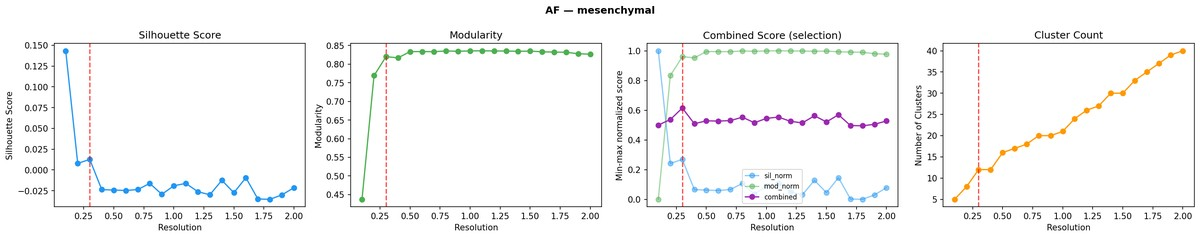

#### Af Non Mesenchymal

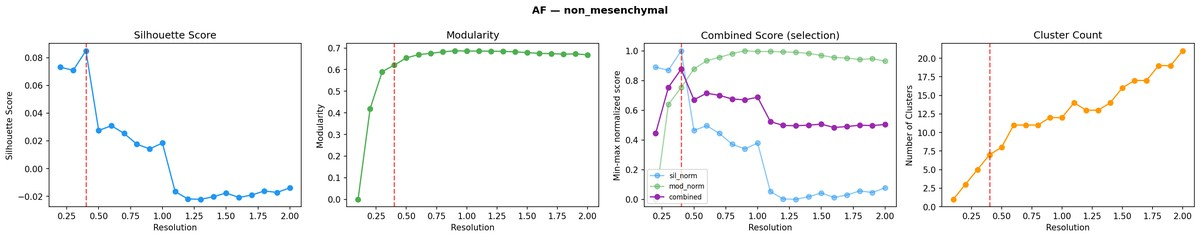

#### Cep Mesenchymal

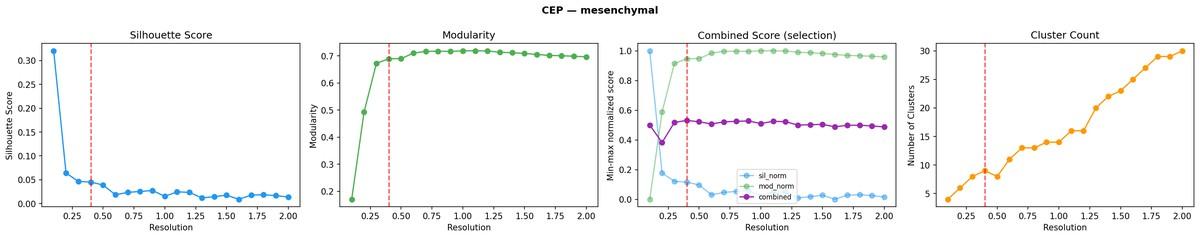

#### Cep Non Mesenchymal

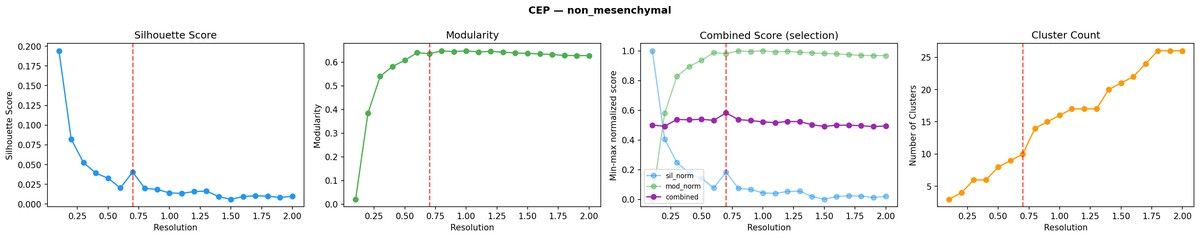

#### Np Mesenchymal

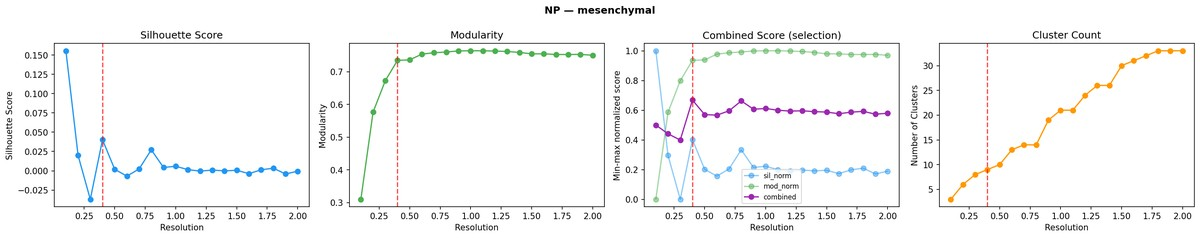

#### Np Non Mesenchymal

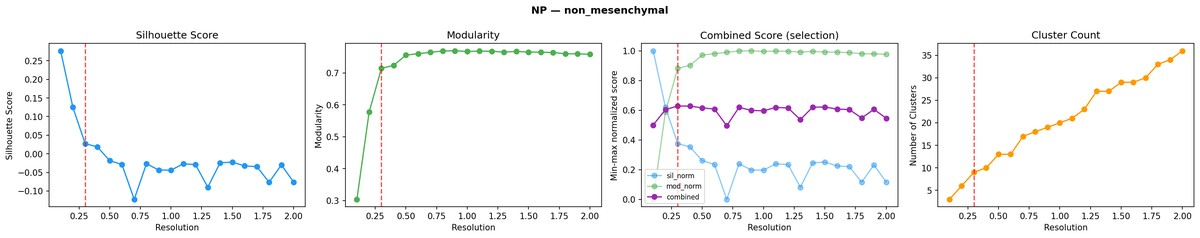

#### All Cells Mesenchymal

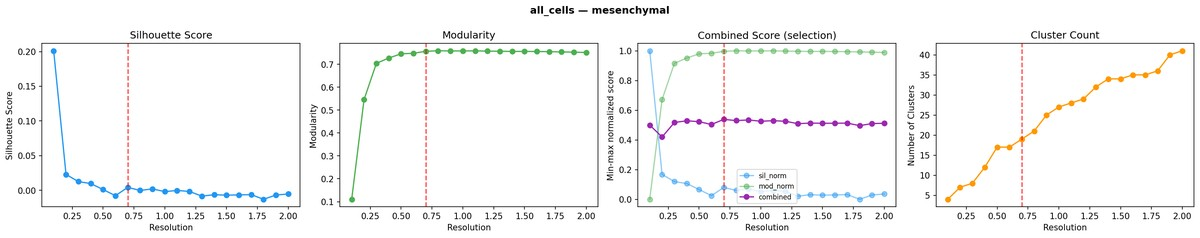

#### All Cells Non Mesenchymal

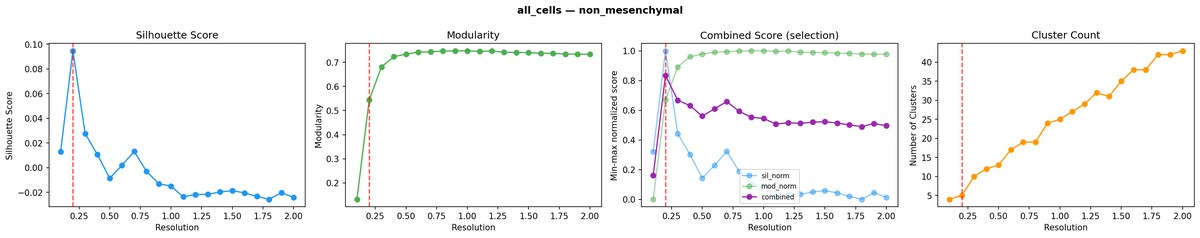

In [8]:
tv4_opt_plots = sorted(TV4_OPT_DIR.glob('*_optimization.png'))
print(f'Tiered v4 resolution optimization plots: {len(tv4_opt_plots)}')

for fpath in tv4_opt_plots:
    label = fpath.stem.replace('_optimization', '').replace('_', ' ').title()
    display(Markdown(f'#### {label}'))
    jpeg_bytes = _encode_jpeg(PILImage.open(fpath))
    display(Image(data=jpeg_bytes, format='jpeg'))


### 5c. Resolution scan tables — tiered v4

Full per-resolution silhouette and modularity values.


In [9]:
tv4_res_tables = sorted(TV4_OPT_DIR.glob('*_resolutions.tsv'))
print(f'Tiered v4 resolution scan tables: {len(tv4_res_tables)}')

for fpath in tv4_res_tables:
    label = fpath.stem.replace('_resolutions', '').replace('_', ' ').title()
    df = pd.read_csv(fpath, sep='\t')
    display(Markdown(f'#### {label}'))
    display(df.style.set_caption(f'{label} — Resolution Scan Results').format(precision=4))


Tiered v4 resolution scan tables: 8


#### Af Mesenchymal

,resolution,n_clusters,silhouette,modularity,sil_norm,mod_norm,combined
0,0.1000,5,0.1435,0.4372,1.0000,0.0000,0.5000
1,0.2000,8,0.0078,0.7692,0.2412,0.8325,0.5369
2,0.3000,12,0.0127,0.8202,0.2689,0.9605,0.6147
3,0.4000,12,-0.0237,0.8170,0.0653,0.9524,0.5088
4,0.5000,16,-0.0242,0.8337,0.0623,0.9945,0.5284
5,0.6000,17,-0.0248,0.8337,0.0593,0.9944,0.5269
6,0.7000,18,-0.0236,0.8335,0.0658,0.9939,0.5299
7,0.8000,20,-0.0162,0.8354,0.1070,0.9987,0.5529
8,0.9000,20,-0.0293,0.8347,0.0338,0.9969,0.5154
9,1.0000,21,-0.0191,0.8354,0.0908,0.9987,0.5448


#### Af Non Mesenchymal

,resolution,n_clusters,silhouette,modularity,sil_norm,mod_norm,combined
0,0.1000,1,nan,0.0000,nan,nan,nan
1,0.2000,3,0.0731,0.4197,0.8892,0.0000,0.4446
2,0.3000,5,0.0709,0.5907,0.8687,0.6391,0.7539
3,0.4000,7,0.0850,0.6210,1.0000,0.7523,0.8762
4,0.5000,8,0.0275,0.6543,0.4637,0.8770,0.6703
5,0.6000,11,0.0309,0.6693,0.4952,0.9328,0.7140
6,0.7000,11,0.0254,0.6755,0.4435,0.9561,0.6998
7,0.8000,11,0.0176,0.6820,0.3706,0.9804,0.6755
8,0.9000,12,0.0142,0.6873,0.3394,1.0000,0.6697
9,1.0000,12,0.0184,0.6860,0.3789,0.9952,0.6871


...

,resolution,n_clusters,silhouette,modularity,sil_norm,mod_norm,combined
0,0.1000,3,0.2768,0.3038,1.0000,0.0000,0.5000
1,0.2000,6,0.1249,0.5779,0.6194,0.5882,0.6038
2,0.3000,9,0.0274,0.7145,0.3750,0.8816,0.6283
3,0.4000,10,0.0186,0.7240,0.3528,0.9020,0.6274
4,0.5000,13,-0.0184,0.7561,0.2602,0.9708,0.6155
5,0.6000,13,-0.0287,0.7605,0.2345,0.9804,0.6074
6,0.7000,17,-0.1222,0.7648,0.0000,0.9896,0.4948
7,0.8000,18,-0.0266,0.7691,0.2395,0.9987,0.6191
8,0.9000,19,-0.0436,0.7697,0.1970,1.0000,0.5985
9,1.0000,20,-0.0439,0.7675,0.1962,0.9954,0.5958


#### All Cells Mesenchymal

,resolution,n_clusters,silhouette,modularity,sil_norm,mod_norm,combined
0,0.1000,4,0.2012,0.1105,1.0000,0.0000,0.5000
1,0.2000,7,0.0229,0.5459,0.1676,0.6714,0.4195
2,0.3000,8,0.0125,0.7041,0.1191,0.9153,0.5172
3,0.4000,12,0.0097,0.7273,0.1061,0.9511,0.5286
4,0.5000,17,0.0011,0.7457,0.0657,0.9794,0.5226
5,0.6000,17,-0.0078,0.7481,0.0244,0.9831,0.5038
6,0.7000,19,0.0042,0.7567,0.0801,0.9964,0.5383
7,0.8000,21,-0.0002,0.7590,0.0598,1.0000,0.5299
8,0.9000,25,0.0020,0.7582,0.0700,0.9987,0.5343
9,1.0000,27,-0.0019,0.7583,0.0518,0.9990,0.5254


#### All Cells Non Mesenchymal

,resolution,n_clusters,silhouette,modularity,sil_norm,mod_norm,combined
0,0.1000,4,0.0129,0.1321,0.3203,0.0000,0.1602
1,0.2000,5,0.0948,0.5432,1.0000,0.6679,0.8339
2,0.3000,10,0.0276,0.6811,0.4418,0.8918,0.6668
3,0.4000,12,0.0107,0.7230,0.3016,0.9598,0.6307
4,0.5000,13,-0.0085,0.7337,0.1419,0.9772,0.5596
5,0.6000,17,0.0019,0.7418,0.2290,0.9905,0.6097
6,0.7000,19,0.0132,0.7435,0.3224,0.9932,0.6578
7,0.8000,19,-0.0029,0.7461,0.1888,0.9974,0.5931
8,0.9000,24,-0.0130,0.7472,0.1051,0.9992,0.5522
9,1.0000,25,-0.0150,0.7477,0.0884,1.0000,0.5442


### 5d. Cluster UMAPs per compartment-tier — tiered v4

UMAPs are stored per tier in `obsm['X_umap']`. Each tier is plotted
separately and colored by its tier-specific Leiden labels
(`leiden_mesenchymal`, `leiden_non_mesenchymal`).


#### NP

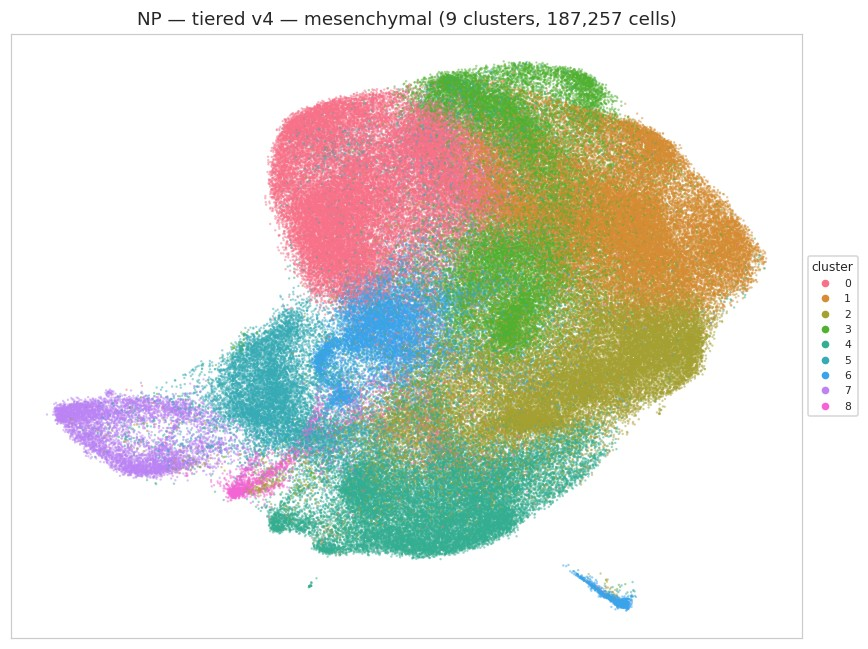

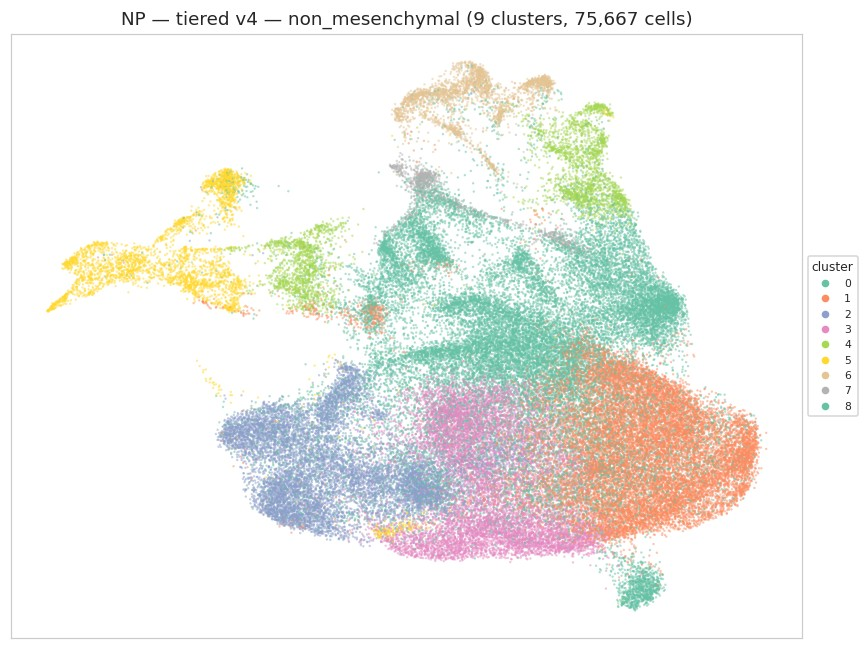

#### AF

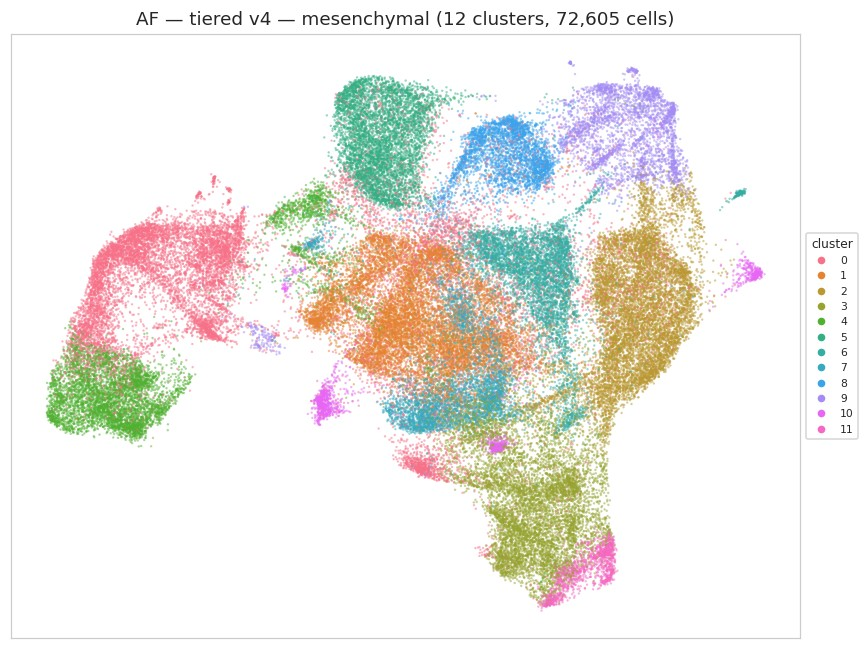

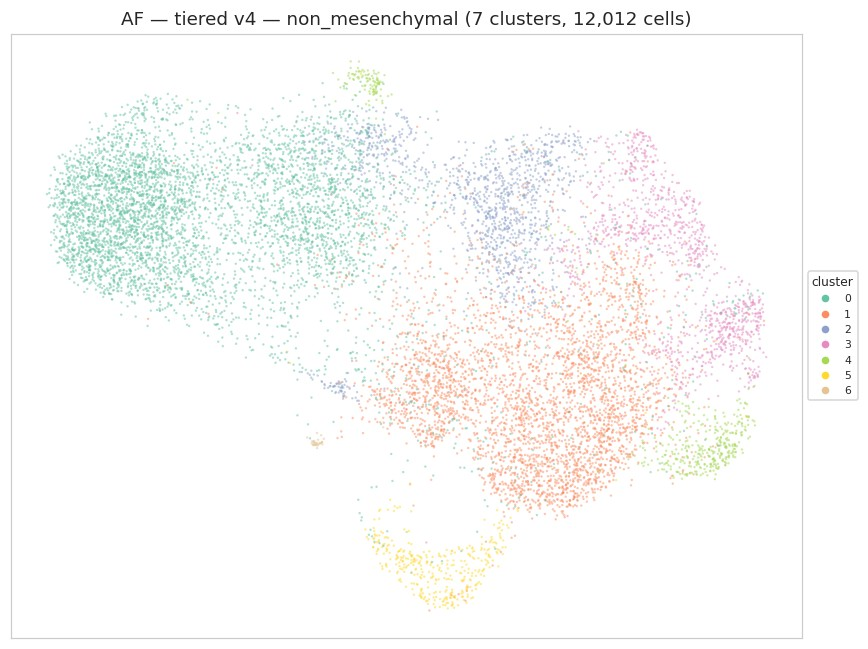

#### CEP

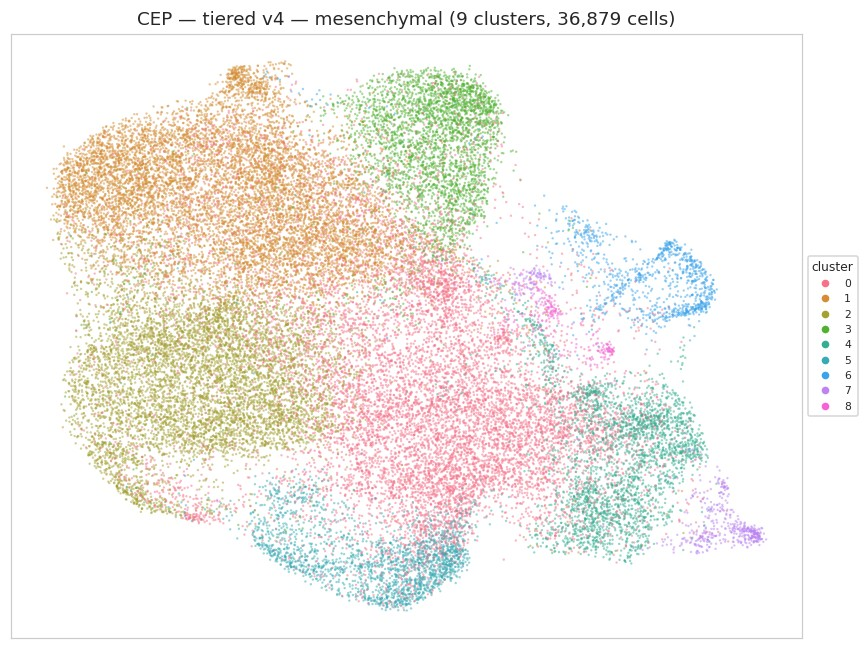

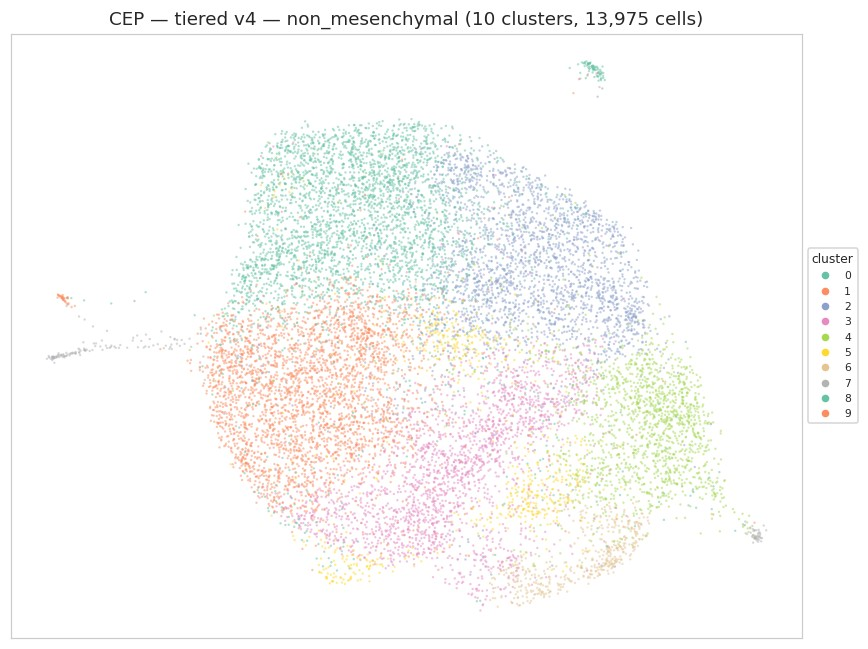

#### all_cells

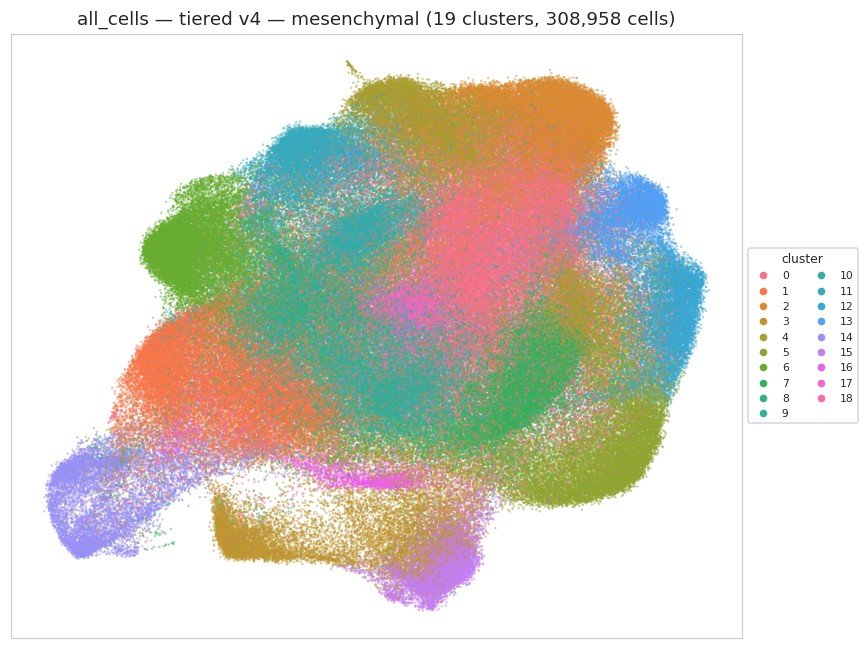

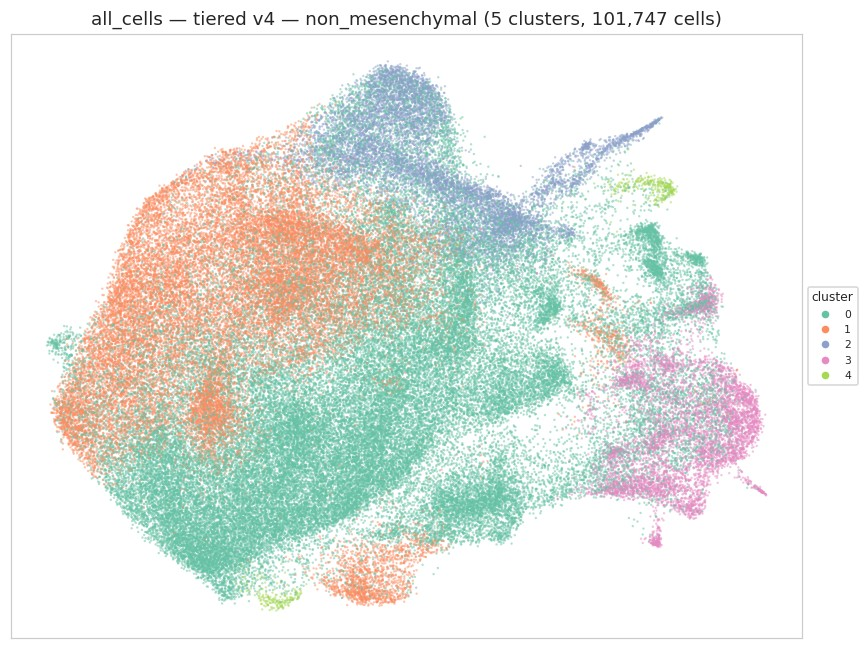

In [10]:
def _plot_tier_umap(comp_name, comp_path, tier, leiden_col, palette_name='husl'):
    adata = sc.read_h5ad(comp_path, backed='r')
    obs = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    if leiden_col not in obs.columns or 'tier' not in obs.columns:
        adata.file.close()
        return False
    mask = (obs['tier'].astype(str) == tier) & (obs[leiden_col].astype(str) != 'NA')
    if mask.sum() < 5:
        adata.file.close()
        return False
    umap = adata.obsm['X_umap'][:][mask.values]
    labels = obs.loc[mask, leiden_col].astype(str).values
    adata.file.close()

    finite = np.isfinite(umap).all(axis=1)
    umap = umap[finite]; labels = labels[finite]
    if len(umap) < 5:
        return False

    uniq = sorted(set(labels), key=lambda x: int(x) if x.isdigit() else x)
    palette = dict(zip(uniq, sns.color_palette(palette_name, max(len(uniq), 8))))
    idx = np.random.RandomState(42).permutation(len(umap))
    colors = [palette[labels[i]] for i in idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.3, alpha=0.5, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{comp_name} — tiered v4 — {tier} '
                 f'({len(uniq)} clusters, {len(umap):,} cells)', fontsize=12)
    handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[c],
                       markersize=6, label=c) for c in uniq]
    ax.legend(handles=handles, title='cluster', fontsize=7, title_fontsize=8,
              loc='center left', bbox_to_anchor=(1.0, 0.5),
              ncol=2 if len(uniq) > 12 else 1)
    fig.tight_layout()
    render_fig(fig)
    return True

for comp_name, comp_path in TV4_COMPARTMENTS.items():
    display(Markdown(f'#### {comp_name}'))
    _plot_tier_umap(comp_name, comp_path, 'mesenchymal', 'leiden_mesenchymal')
    plotted_nm = _plot_tier_umap(comp_name, comp_path, 'non_mesenchymal',
                                  'leiden_non_mesenchymal', palette_name='Set2')
    if not plotted_nm:
        print(f'  {comp_name}: no non_mesenchymal tier (or too few cells)')


### 5e. Cluster size distributions — tiered v4

Per-tier cluster sizes for each compartment.


#### NP

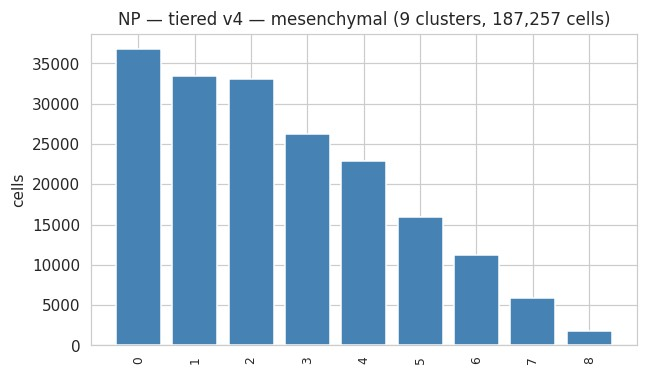

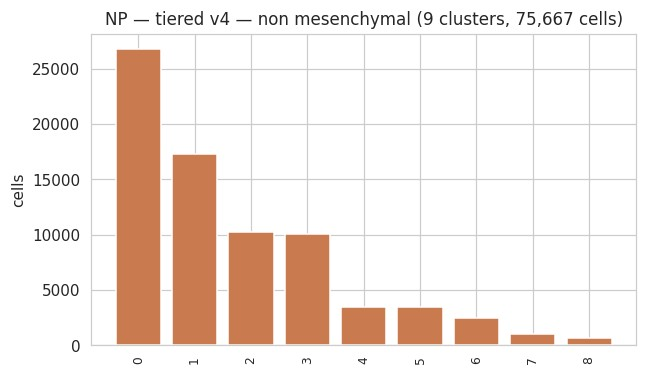

#### AF

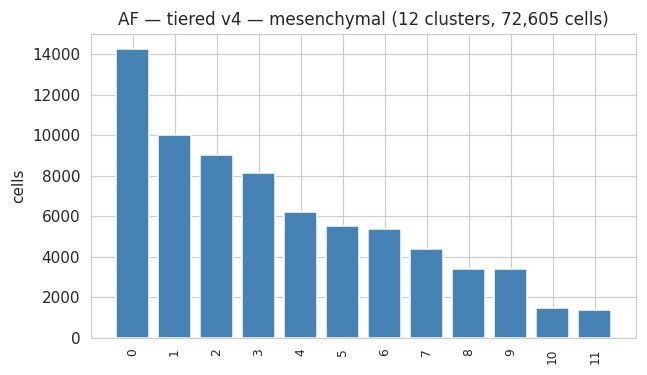

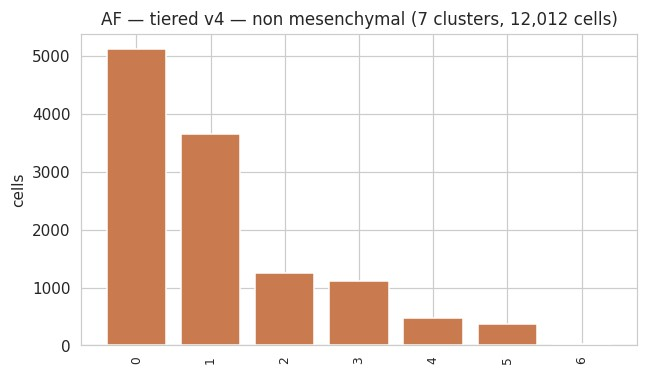

#### CEP

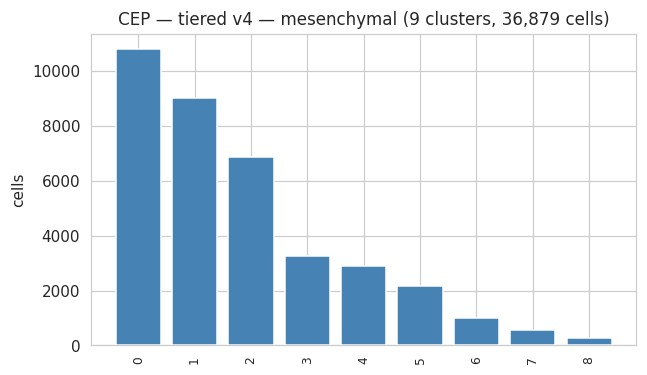

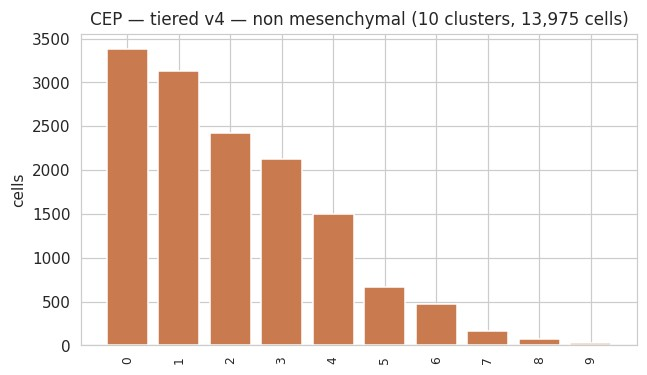

#### all_cells

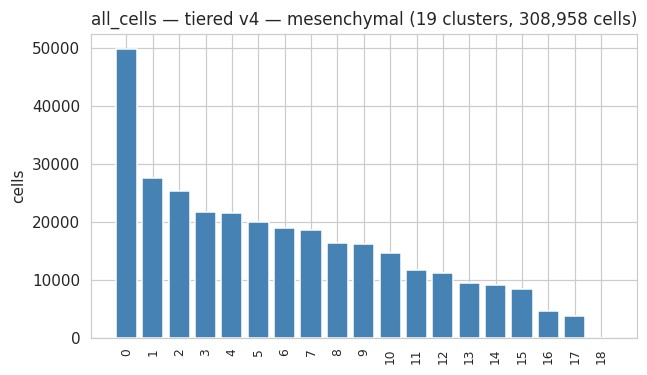

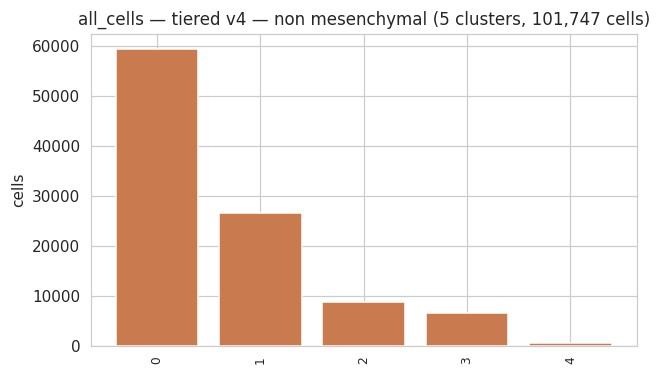

In [11]:
def _bar_tier_clusters(comp_name, comp_path, leiden_col, color):
    adata = sc.read_h5ad(comp_path, backed='r')
    obs = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()
    if leiden_col not in obs.columns:
        return False
    s = obs[leiden_col].astype(str)
    s = s[s != 'NA']
    if len(s) == 0:
        return False
    counts = s.value_counts().sort_index(
        key=lambda x: x.astype(int) if x.str.isdigit().all() else x)
    fig, ax = plt.subplots(figsize=(max(6, len(counts) * 0.3), 3.5))
    ax.bar(range(len(counts)), counts.values, color=color, edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=90, fontsize=8)
    ax.set_ylabel('cells')
    tier_label = leiden_col.replace('leiden_', '').replace('_', ' ')
    ax.set_title(f'{comp_name} — tiered v4 — {tier_label} '
                 f'({len(counts)} clusters, {len(s):,} cells)', fontsize=11)
    fig.tight_layout()
    render_fig(fig)
    return True

for comp_name, comp_path in TV4_COMPARTMENTS.items():
    display(Markdown(f'#### {comp_name}'))
    _bar_tier_clusters(comp_name, comp_path, 'leiden_mesenchymal', 'steelblue')
    plotted_nm = _bar_tier_clusters(comp_name, comp_path, 'leiden_non_mesenchymal', '#c97a4f')
    if not plotted_nm:
        print(f'  {comp_name}: no non_mesenchymal tier')


### 5f. Resolution decisions (2026-05-22)

The six open questions from the 2026-05-22 review were resolved in favor of
the statistically-selected resolutions (no manual overrides):

1. **NP mes (9 clusters at res = 0.4).** Accepted — both metrics agree on the
   peak; the 6 fibrocartilaginous clusters that collapse to a single cell
   type at Module 07 are sub-states of NP_fibrocartilaginous, captured in the
   new `cell_subtype` column (Module 07 Stage 3).
2. **NP non-mes (9 clusters at res = 0.3).** Accepted.
3. **CEP mes (9 clusters at res = 0.4).** Accepted — coarser than 2026-05-09
   because removing mis-tiered non-mes contamination flattens modularity.
4. **CEP non-mes (10 clusters at res = 0.7).** Accepted.
5. **all_cells mes (19 clusters at res = 0.7).** Accepted — per-compartment
   vs unified atlas cluster count comparison deferred (not the right scale
   for this stage).
6. **all_cells non-mes (5 clusters at res = 0.2).** Accepted — highest
   combined score of any tier in the rerun.

Phase-5 gates (DE concordance ≥ 80 % top-100 with v5; ≥ 5/10 pain genes
recovered; max_study_pct < 85 %; pseudobulk power ≥ v5's 17 powered
comparisons) will be evaluated as Module 08 lands.


### 5g. Cluster → cell_subtype mapping (tiered v4, 2026-05-22)

Each compartment's mesenchymal-tier clusters are mapped to a
`cell_subtype` label by Module 07 Stage 3 (overlap-based scoring against
`SUBSTATE_PANELS`: `proliferating`, `inflammatory`, `stressed`,
`matrix_active`, `migratory`, `homeostatic` fallback, plus
`endothelial_admixed` contamination flag). The table below preserves the
statistical cluster IDs alongside the biological sub-state labels, so the
clusters can still be referenced individually for DE / pseudobulk while
the sub-state column is used for descriptive characterization and
composition tests.

Non-mesenchymal cells skip Stage 3 (their existing fine labels —
`Macrophage_M1/M2`, `Neutrophil`, `Erythrocyte`, etc. — are already
specific enough); `cell_subtype = cell_type` for those cells.


In [12]:
rows = []
for comp_name, comp_path in TV4_COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_cols = ['tier', 'leiden_mesenchymal', 'cell_type', 'cell_subtype']
    have = [c for c in obs_cols if c in adata.obs.columns]
    obs = adata.obs[have].copy()
    adata.file.close()
    if 'cell_subtype' not in obs.columns:
        continue
    mes = obs[obs['tier'] == 'mesenchymal'].copy()
    if len(mes) == 0:
        continue
    for cluster in sorted(mes['leiden_mesenchymal'].astype(str).unique(),
                          key=lambda x: int(x)):
        sub = mes[mes['leiden_mesenchymal'].astype(str) == cluster]
        ct = sub['cell_type'].mode().iloc[0]
        st = sub['cell_subtype'].mode().iloc[0]
        rows.append({
            'compartment': comp_name,
            'leiden_mesenchymal': cluster,
            'n_cells': len(sub),
            'cell_type': ct,
            'cell_subtype': st,
        })
df = pd.DataFrame(rows)
display(df.style.set_caption(
    'Module 06 mesenchymal clusters → Module 07 Stage 3 cell_subtype'
).hide(axis='index').format({'n_cells': '{:,}'}))


compartment,leiden_mesenchymal,n_cells,cell_type,cell_subtype
NP,0,"36,803",NP_fibrocartilaginous,NP_fibrocartilaginous_stressed
NP,1,"33,387",NP_fibrochondrocyte_chondroid,NP_fibrochondrocyte_chondroid_homeostatic
NP,2,"33,010",NP_mature_chondrocyte,NP_mature_chondrocyte_matrix_active
NP,3,"26,263",NP_fibrochondrocyte_chondroid,NP_fibrochondrocyte_chondroid_homeostatic
NP,4,"22,897",NP_fibrocartilaginous,NP_fibrocartilaginous_matrix_active
NP,5,"15,915",NP_fibrocartilaginous,NP_fibrocartilaginous_migratory
NP,6,"11,252",NP_fibrocartilaginous,NP_fibrocartilaginous_inflammatory
NP,7,"5,899",NP_fibrocartilaginous,NP_fibrocartilaginous_proliferating
NP,8,"1,831",NP_fibrocartilaginous,NP_fibrocartilaginous_endothelial_admixed
AF,0,"14,288",AF_inner,AF_inner_homeostatic


## 6. Status

### v5 atlas (CCA-flat) — Module 06 complete (2026-03-25)
- Leiden clustering on CCA latent space with automated resolution optimization
- Separate clustering for mesenchymal and non-mesenchymal tiers
- NP: 12 · AF: 12 · CEP: 9 · all_cells: 15 clusters
- Cluster labels stored in `leiden`; tier-specific in `leiden_mesenchymal`,
  `leiden_non_mesenchymal`

### Tiered v4 atlas — Module 06 complete, awaiting human checkpoint (2026-05-22 rerun)
- Leiden clustering on per-tier Seurat v4 SCT + CCA embeddings
- Selection: argmax of equal-weighted normalized silhouette+modularity
  combined score over the full sweep res = 0.1 → 2.0 (PR #4, `d44a0c4`)
- NP: 18 (9 mes @ res 0.4 + 9 non-mes @ res 0.3)
- AF: 19 (12 mes @ res 0.3 + 7 non-mes @ res 0.4)
- CEP: 19 (9 mes @ res 0.4 + 10 non-mes @ res 0.7)
- all_cells: 24 (19 mes @ res 0.7 + 5 non-mes @ res 0.2)
- All blob and study-cluster ARI checks pass (max ARI 0.102, CEP)
- Cluster labels stored in `leiden` (with `M`/`NM` prefix), `leiden_mesenchymal`,
  `leiden_non_mesenchymal`
- **Pipeline stopped at the human checkpoint before Module 07.**
  See §5f for review questions.